In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as imbPipeline
from imblearn.over_sampling import SMOTE 
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from lightgbm import LGBMClassifier

# Credit Card Fraud Detection: EDA & Modeling

## Setup & Data Loading

In [43]:
df = pd.read_csv(r'C:\Users\ASUS\Credit_card_fraud_detection\Data\raw\train_transaction.csv')

In [44]:
df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [45]:
df.shape

(590540, 394)

In [46]:
df['isFraud']

0         0
1         0
2         0
3         0
4         0
         ..
590535    0
590536    0
590537    0
590538    0
590539    0
Name: isFraud, Length: 590540, dtype: int64

In [47]:
df_id = pd.read_csv(r'C:\Users\ASUS\Credit_card_fraud_detection\Data\raw\train_identity.csv')

## Exploratory Data Analysis

In [48]:
df_id.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 394 entries, TransactionID to V339
dtypes: float64(376), int64(4), str(14)
memory usage: 1.7 GB


In [50]:
df_id.info()

<class 'pandas.DataFrame'>
RangeIndex: 144233 entries, 0 to 144232
Data columns (total 41 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionID  144233 non-null  int64  
 1   id_01          144233 non-null  float64
 2   id_02          140872 non-null  float64
 3   id_03          66324 non-null   float64
 4   id_04          66324 non-null   float64
 5   id_05          136865 non-null  float64
 6   id_06          136865 non-null  float64
 7   id_07          5155 non-null    float64
 8   id_08          5155 non-null    float64
 9   id_09          74926 non-null   float64
 10  id_10          74926 non-null   float64
 11  id_11          140978 non-null  float64
 12  id_12          144233 non-null  str    
 13  id_13          127320 non-null  float64
 14  id_14          80044 non-null   float64
 15  id_15          140985 non-null  str    
 16  id_16          129340 non-null  str    
 17  id_17          139369 non-null  float64


In [51]:
df.isna()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,False,False,False,False,False,False,True,False,False,False,...,True,True,True,True,True,True,True,True,True,True
1,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,True,True
2,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,True,True
3,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,True,True
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590535,False,False,False,False,False,False,True,False,False,False,...,True,True,True,True,True,True,True,True,True,True
590536,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,True,True
590537,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,True,True
590538,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,True,True


In [52]:
miss = df.isnull().sum().sort_values(ascending=False)

miss.head(20)

dist2    552913
D7       551623
D13      528588
D14      528353
D12      525823
D6       517353
D9       515614
D8       515614
V153     508595
V149     508595
V141     508595
V146     508595
V154     508595
V162     508595
V142     508595
V158     508595
V161     508595
V157     508595
V138     508595
V139     508595
dtype: int64

In [53]:
df['isFraud'].value_counts(normalize=True)*100

isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64

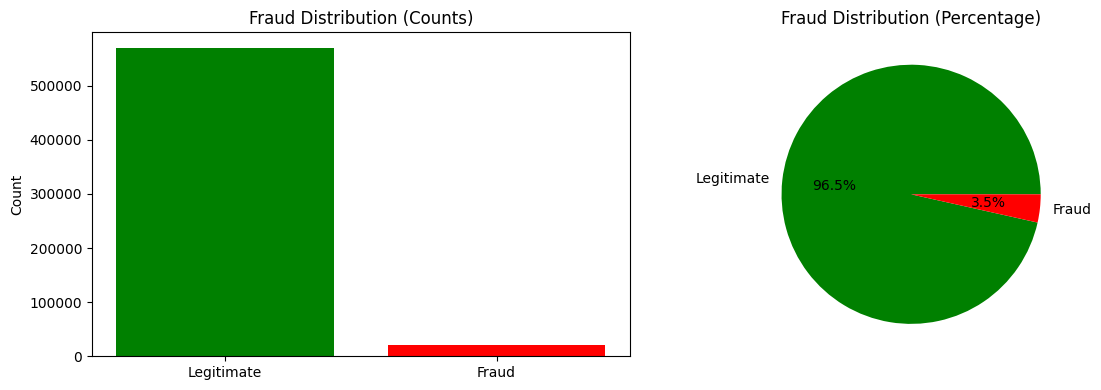

Total transactions: 590540
Fraud: 20663 (3.50%)
Legitimate: 569877 (96.50%)


In [75]:
# Target distribution visualization
fraud_counts = df['isFraud'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Legitimate', 'Fraud'], fraud_counts.values, color=['green', 'red'])
axes[0].set_title('Fraud Distribution (Counts)')
axes[0].set_ylabel('Count')

df['isFraud'].value_counts(normalize=True).plot(kind='pie', ax=axes[1], labels=['Legitimate', 'Fraud'], autopct='%1.1f%%', colors=['green', 'red'])
axes[1].set_title('Fraud Distribution (Percentage)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print(f"Total transactions: {len(df)}")
print(f"Fraud: {fraud_counts[1]} ({fraud_counts[1]/len(df)*100:.2f}%)")
print(f"Legitimate: {fraud_counts[0]} ({fraud_counts[0]/len(df)*100:.2f}%)")

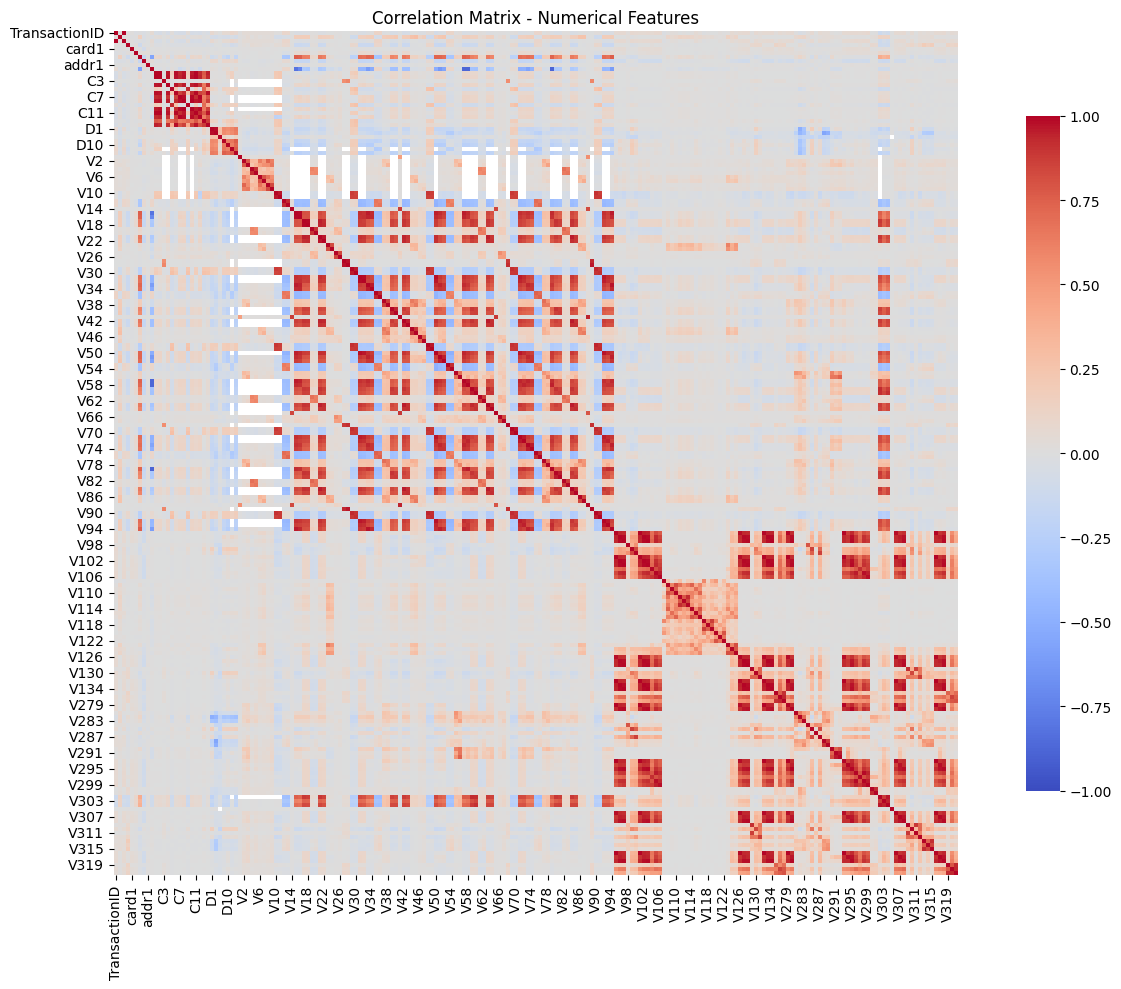

In [76]:
# Correlation heatmap for numerical features
numeric_df = df.select_dtypes(include=[np.number])
numeric_df_subset = numeric_df.dropna(axis=1, thresh=len(numeric_df)*0.5)  # Keep columns with >50% data

plt.figure(figsize=(14, 10))
corr_matrix = numeric_df_subset.corr()
sb.heatmap(corr_matrix, cmap='coolwarm', center=0, vmin=-1, vmax=1, square=True, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Numerical Features')
plt.tight_layout()
plt.show()

In [77]:
# Feature variance and distribution analysis
feature_stats = numeric_df.describe().T
feature_stats['variance'] = numeric_df.var()
feature_stats_sorted = feature_stats.sort_values('variance', ascending=False)

print("Top 15 Features by Variance:")
print(feature_stats_sorted[['count', 'mean', 'std', 'variance']].head(15))

Top 15 Features by Variance:
                  count          mean           std      variance
TransactionDT  590540.0  7.372311e+06  4.617224e+06  2.131875e+13
TransactionID  590540.0  3.282270e+06  1.704744e+05  2.906151e+10
V160            81951.0  4.745318e+04  1.420761e+05  2.018561e+10
V332            82351.0  1.375784e+03  1.116928e+04  1.247527e+08
V203           139631.0  1.078328e+03  9.105608e+03  8.291210e+07
V159            81951.0  2.719300e+03  8.355445e+03  6.981346e+07
V165            81951.0  2.239912e+03  8.223259e+03  6.762199e+07
V333            82351.0  1.014623e+03  7.955735e+03  6.329373e+07
V212           139631.0  7.659883e+02  7.496121e+03  5.619183e+07
V331            82351.0  7.217419e+02  6.217224e+03  3.865387e+07
V164            81951.0  8.778889e+02  6.049167e+03  3.659242e+07
V204           139631.0  6.869569e+02  6.048981e+03  3.659017e+07
V213           139631.0  5.363028e+02  5.471665e+03  2.993911e+07
card1          590540.0  9.898735e+03  4.901170

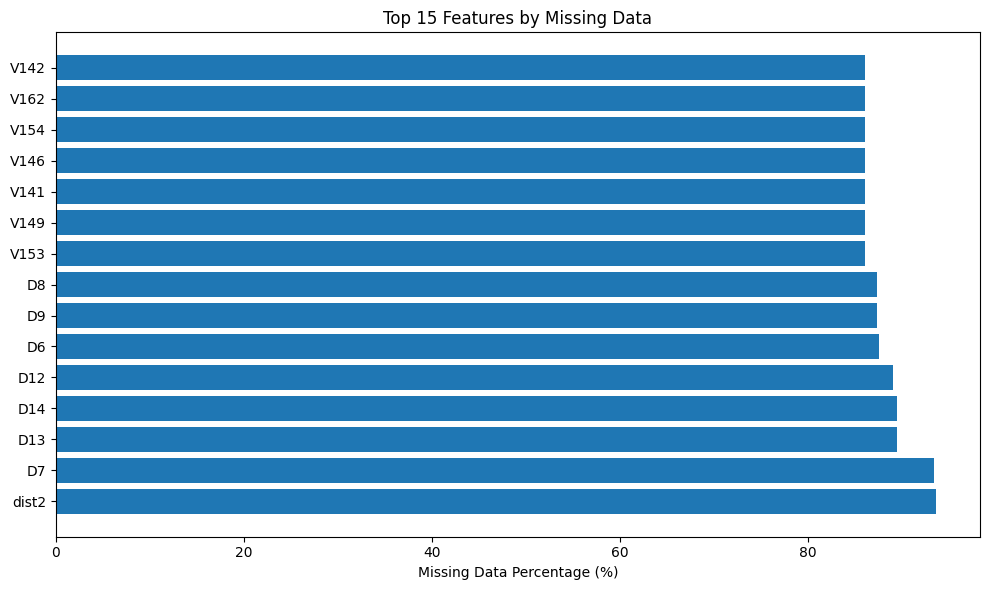

Columns with >90% missing: ['dist2', 'D7']


In [78]:
# Missing value patterns
missing_by_col = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing_by_col / len(df) * 100).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(range(len(missing_pct.head(15))), missing_pct.head(15).values)
plt.yticks(range(len(missing_pct.head(15))), missing_pct.head(15).index)
plt.xlabel('Missing Data Percentage (%)')
plt.title('Top 15 Features by Missing Data')
plt.tight_layout()
plt.show()

print(f"Columns with >90% missing: {missing_pct[missing_pct > 90].index.tolist()}")

In [79]:
# Feature statistics by fraud class
print("Feature Statistics - Fraudulent Transactions:")
print(df[df['isFraud']==1][numeric_df_subset.columns].describe().T[['mean', 'std', '50%']].head(10))
print("\nFeature Statistics - Legitimate Transactions:")
print(df[df['isFraud']==0][numeric_df_subset.columns].describe().T[['mean', 'std', '50%']].head(10))

Feature Statistics - Fraudulent Transactions:
                        mean           std        50%
TransactionID   3.294952e+06  1.620403e+05  3291934.0
isFraud         1.000000e+00  0.000000e+00        1.0
TransactionDT   7.690033e+06  4.416551e+06  7575230.0
TransactionAmt  1.492448e+02  2.322122e+02       75.0
card1           9.547654e+03  4.762051e+03     9633.0
card2           3.653708e+02  1.596235e+02      375.0
card3           1.623686e+02  1.749577e+01      150.0
card5           1.919943e+02  4.577989e+01      224.0
addr1           2.943171e+02  1.035850e+02      299.0
addr2           8.628602e+01  4.936238e+00       87.0

Feature Statistics - Legitimate Transactions:
                        mean           std        50%
TransactionID   3.281810e+06  1.707548e+05  3281808.0
isFraud         0.000000e+00  0.000000e+00        0.0
TransactionDT   7.360791e+06  4.623930e+06  7271678.0
TransactionAmt  1.345117e+02  2.393951e+02       68.5
card1           9.911464e+03  4.905672e+03 

In [81]:
X = df.drop('isFraud',axis=1)
y = df['isFraud']

In [80]:
# Merge transaction and identity data
print(f"Transactions before merge: {df.shape[0]}")
print(f"Identity records: {df_id.shape[0]}")

df_merged = df.merge(df_id, on='TransactionID', how='left')

print(f"Transactions after merge: {df_merged.shape[0]}")
print(f"Transactions with identity data: {df_merged.dropna(subset=df_id.columns[1:]).shape[0]}")
print(f"Transactions without identity data: {df_merged[df_merged[df_id.columns[1]].isnull()].shape[0]}")

df = df_merged

Transactions before merge: 590540
Identity records: 144233
Transactions after merge: 590540
Transactions with identity data: 935
Transactions without identity data: 446307


## Data Integration & Preprocessing

In [82]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [83]:
num_cols = []
obj_cols = []

for col in X_train.columns:
    try:
        # Try converting to numeric
        pd.to_numeric(X_train[col])
        num_cols.append(col)
    except:
        obj_cols.append(col)

In [84]:
num_pipeline = Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='median')),
        ('scaler',StandardScaler())
    ]
)

In [85]:
cat_pipeline = Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='most_frequent')),
        ('one_hot_encoder',OneHotEncoder(handle_unknown='ignore',sparse_output=False))
    ]
)

In [86]:
preprocessor = ColumnTransformer(
    [
        ('num_pipeline',num_pipeline,num_cols),
        ('cat_pipleine',cat_pipeline,obj_cols)
    ]
)

In [87]:
scale = len(y_train[y_train==0]) / len(y_train[y_train==1])

model = Pipeline(
  steps=[
    ('preprocessor',preprocessor),
    ('model',LGBMClassifier(
      n_estimators=2000,
      learning_rate=0.03,
      num_leaves=64,
      max_depth=-1,
      min_child_samples=100,
      
      subsample=0.8,
      colsample_bytree=0.8,

      reg_alpha=0.1,
      reg_lambda=1.0,

      scale_pos_weight=scale,
      n_jobs=-1
    ))
  ]
)

## Model Training

In [88]:
model.fit(X_train,y_train)

[LightGBM] [Info] Number of positive: 16421, number of negative: 456011
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.247796 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 38787
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 714
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034758 -> initscore=-3.323956
[LightGBM] [Info] Start training from score -3.323956


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_pipeline', ...), ('cat_pipleine', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differe

In [89]:
y_train_prob = model.predict_proba(X_train)[:,1]
y_val_prob = model.predict_proba(X_test)[:,1]

c:\Users\ASUS\Credit_card_fraud_detection\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\ASUS\Credit_card_fraud_detection\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [90]:
roc_auc = roc_auc_score(y_test, y_val_prob)
print('roc-auc',roc_auc)

roc-auc 0.9691985493705834


In [91]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(y_test, y_val_prob)
print('pr_auc',pr_auc)

pr_auc 0.8216216838968046


In [92]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(y_test, y_val_prob)

f1 = 2 * (precision * recall) / (precision + recall + 1e-10)

best_idx = np.argmax(f1)

print("Best Threshold:", thresholds[best_idx])
print("Precision:", precision[best_idx])
print("Recall:", recall[best_idx])

Best Threshold: 0.7668699691778915
Precision: 0.8358778625954199
Recall: 0.7227722772277227


In [93]:
y_pred = (y_val_prob > 0.35).astype(int)

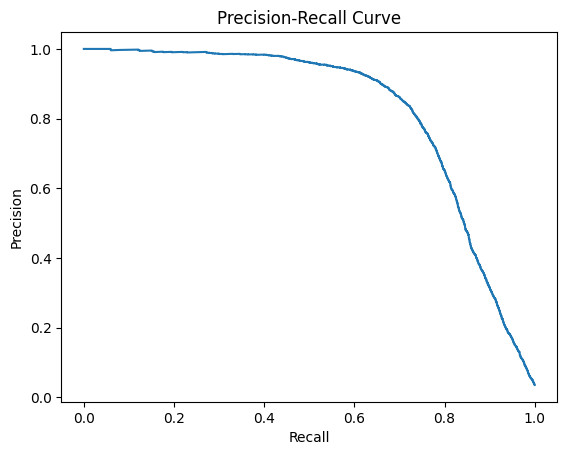

In [94]:
precision, recall, _ = precision_recall_curve(y_test, y_val_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [95]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.94      0.97    113866
           1       0.37      0.88      0.52      4242

    accuracy                           0.94    118108
   macro avg       0.68      0.91      0.74    118108
weighted avg       0.97      0.94      0.95    118108



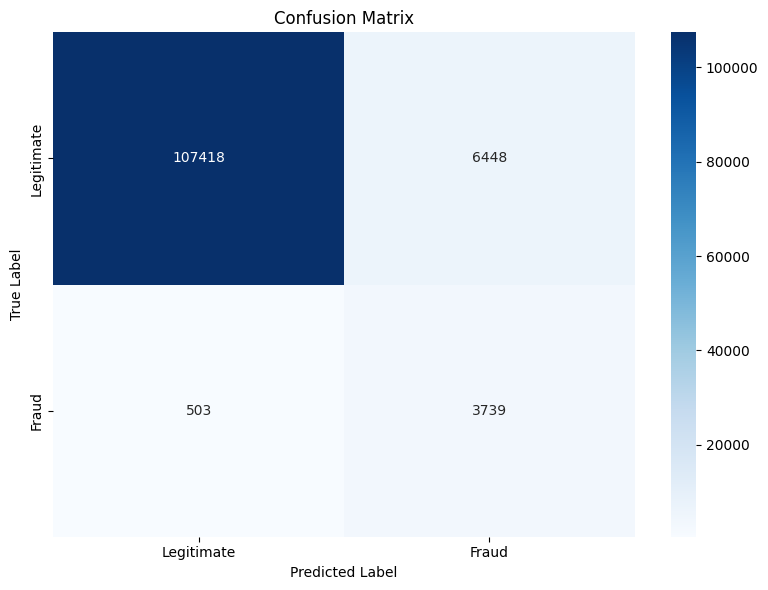

True Negatives: 107418
False Positives: 6448
False Negatives: 503
True Positives: 3739


In [96]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sb.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Legitimate', 'Fraud'], yticklabels=['Legitimate', 'Fraud'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print(f"True Negatives: {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives: {cm[1,1]}")

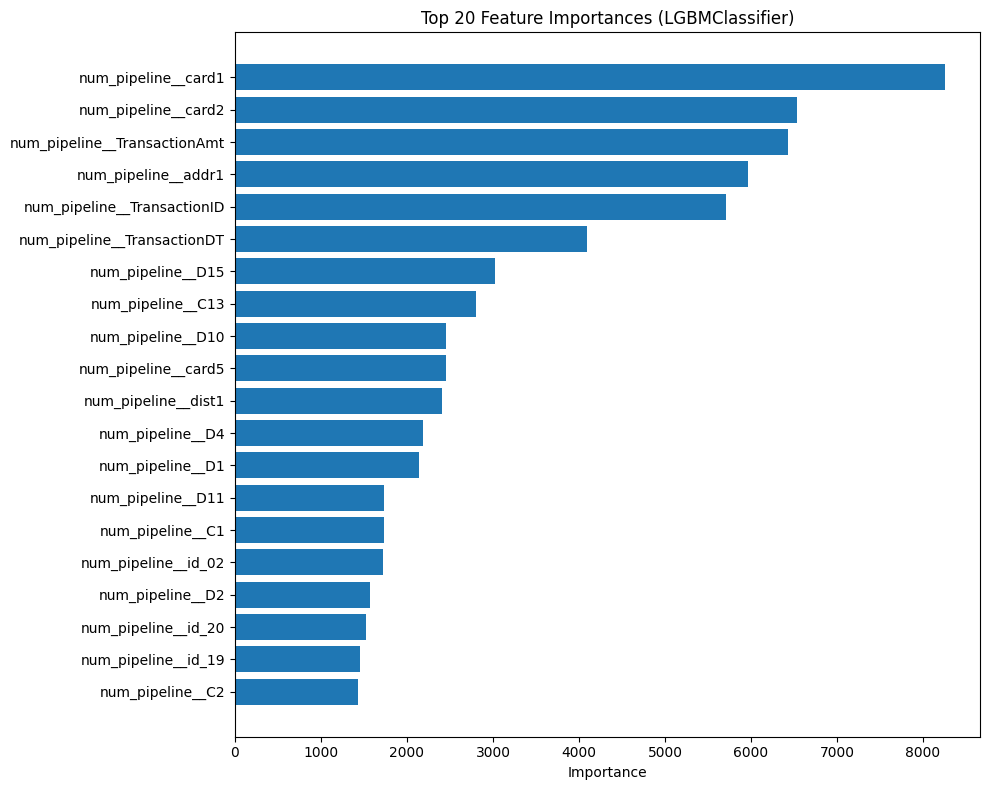

Top 10 Important Features:
                         feature  importance
3            num_pipeline__card1        8250
4            num_pipeline__card2        6531
2   num_pipeline__TransactionAmt        6426
7            num_pipeline__addr1        5961
0    num_pipeline__TransactionID        5708
1    num_pipeline__TransactionDT        4096
39             num_pipeline__D15        3027
23             num_pipeline__C13        2799
34             num_pipeline__D10        2458
6            num_pipeline__card5        2455


In [97]:
# Feature Importance from LGBMClassifier
feature_importance = model.named_steps['model'].feature_importances_
feature_names = model.named_steps['preprocessor'].get_feature_names_out()

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

# Plot top 20 features
plt.figure(figsize=(10, 8))
plt.barh(range(min(20, len(importance_df))), importance_df.head(20)['importance'].values)
plt.yticks(range(min(20, len(importance_df))), importance_df.head(20)['feature'].values)
plt.xlabel('Importance')
plt.title('Top 20 Feature Importances (LGBMClassifier)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 10 Important Features:")
print(importance_df.head(10))

Threshold Comparison:
 Threshold  Accuracy  Precision   Recall  F1-Score
      0.25  0.906543   0.266813 0.916549  0.413309
      0.30  0.926296   0.315533 0.899811  0.467226
      0.35  0.941147   0.367036 0.881424  0.518262
      0.40  0.952188   0.419484 0.862801  0.564510
      0.45  0.960892   0.475155 0.849835  0.609519
      0.50  0.967775   0.532841 0.833805  0.650184


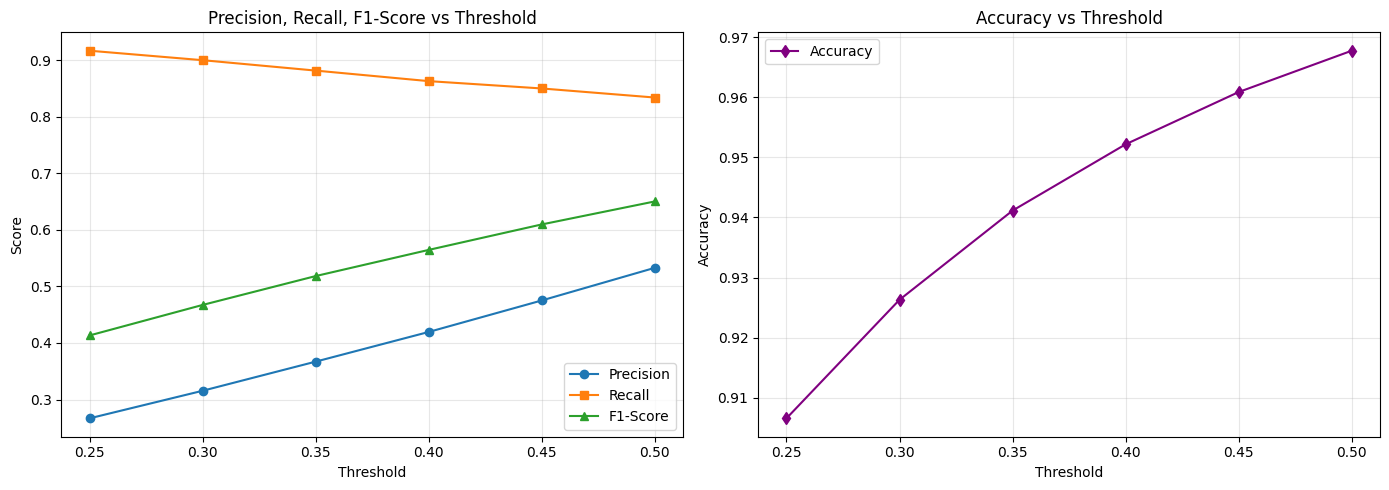

In [98]:
# Threshold Analysis - Compare metrics at different thresholds
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

thresholds_to_test = [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
threshold_results = []

for thresh in thresholds_to_test:
    y_pred_thresh = (y_val_prob > thresh).astype(int)
    
    threshold_results.append({
        'Threshold': thresh,
        'Accuracy': accuracy_score(y_test, y_pred_thresh),
        'Precision': precision_score(y_test, y_pred_thresh, zero_division=0),
        'Recall': recall_score(y_test, y_pred_thresh, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred_thresh, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)
print("Threshold Comparison:")
print(threshold_df.to_string(index=False))

# Plot threshold comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(threshold_df['Threshold'], threshold_df['Precision'], marker='o', label='Precision')
axes[0].plot(threshold_df['Threshold'], threshold_df['Recall'], marker='s', label='Recall')
axes[0].plot(threshold_df['Threshold'], threshold_df['F1-Score'], marker='^', label='F1-Score')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Precision, Recall, F1-Score vs Threshold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(threshold_df['Threshold'], threshold_df['Accuracy'], marker='d', color='purple', label='Accuracy')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy vs Threshold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Model Evaluation